In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [37]:
#loading and preprocessing data
data = pd.read_json("Amazon_Fashion.jsonl", lines=True)

In [38]:
data = data[data["rating"] != 3]

In [39]:
data = data[data["timestamp"] > '2015-01-01']

In [40]:
data["year"] = data["timestamp"].apply(lambda x: x.year)
data["month"] = data["timestamp"].apply(lambda x: x.month)
data["day"] = data["timestamp"].apply(lambda x: x.day)

In [41]:
#binarization of reviews to train ctr-predictor
data["rating"] = data["rating"].transform(lambda x: 1 if x > 3 else 0)

In [42]:
data.set_index(data["timestamp"],inplace=True)

In [43]:
data.sort_index(inplace=True)

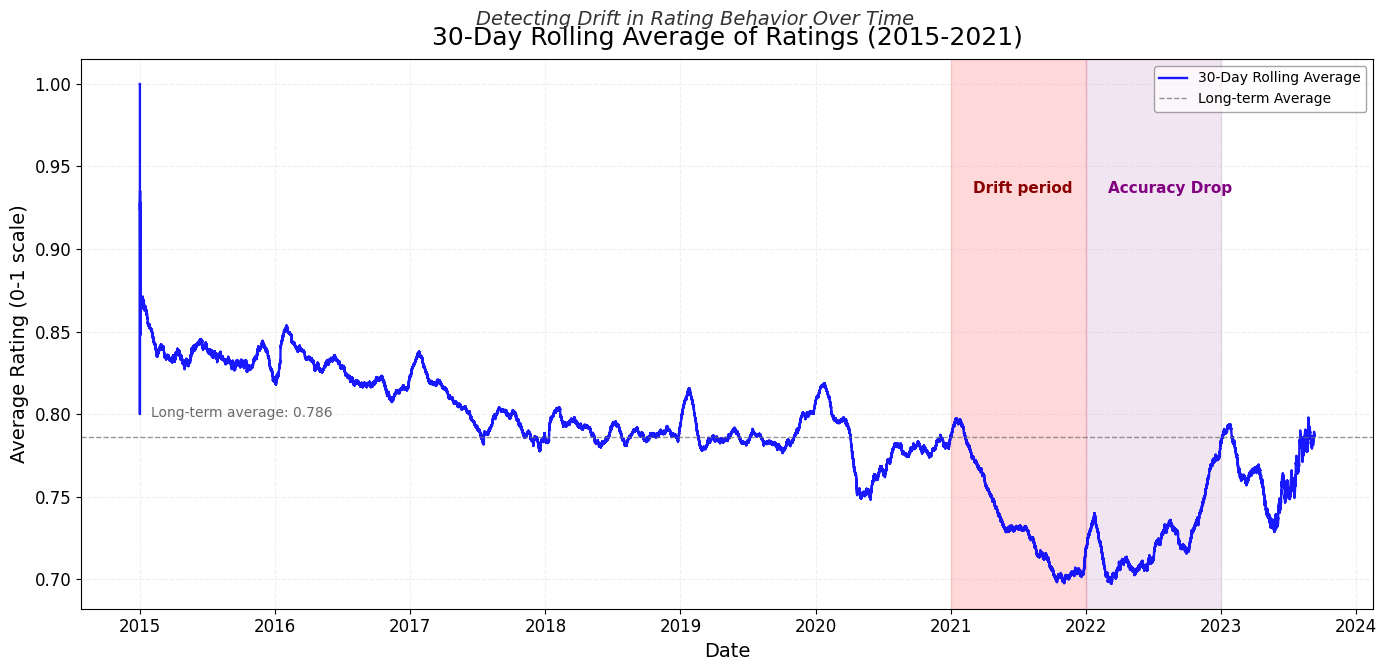

In [44]:
# # Set style to white background instead of dark
plt.style.use("default")  # Using default style for white background

# Create figure and axis with adjusted size for better layout
fig, ax = plt.subplots(figsize=(14, 7))

# Plot the 30-day rolling average with thinner line
rolling_avg = data["rating"].rolling("30D").mean()
ax.plot(rolling_avg.index, rolling_avg, color='blue', linewidth=1.7, alpha=0.9)

# Calculate and add long-term average reference line
long_term_avg = data["rating"].mean()
ax.axhline(y=long_term_avg, color='dimgray', linestyle='--', linewidth=1, alpha=0.7)
ax.text(data.index.min() + pd.Timedelta(days=30), long_term_avg + 0.01,
        f'Long-term average: {long_term_avg:.3f}',
        color='dimgray', fontsize=10, verticalalignment='bottom')

# Add shaded region to mark drift period
drift_start = pd.Timestamp('2021-01-01')
drift_end = pd.Timestamp('2022-01-01')  # Assuming drift period extends to 2022
ax.axvspan(drift_start, drift_end, color='red', alpha=0.15)
ax.text(drift_start + pd.Timedelta(days=60), ax.get_ylim()[1] * 0.92, 'Drift period',
        color='darkred', fontsize=11, fontweight='bold')


# Highlight accuracy drop period (2022 to 2023)
drop_start = pd.Timestamp('2022-01-01')
drop_end = pd.Timestamp('2023-01-01')
ax.axvspan(drop_start, drop_end, color='purple', alpha=0.1)
ax.text(drop_start + pd.Timedelta(days=60), ax.get_ylim()[1] * 0.92,
        'Accuracy Drop', color='purple', fontsize=11, fontweight='bold')


# Add title and subtitle with increased font sizes
ax.set_title('30-Day Rolling Average of Ratings (2015-2021)', fontsize=18, pad=10, color='black')
plt.figtext(0.5, 0.93, 'Detecting Drift in Rating Behavior Over Time',
            ha='center', fontsize=14, style='italic', color='#333333')

# Add labels with increased font sizes
ax.set_xlabel('Date', fontsize=14, color='black')
ax.set_ylabel('Average Rating (0-1 scale)', fontsize=14, color='black')

# Format x-axis to show only year markers to reduce clutter
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.xticks(fontsize=12, color='black')
plt.yticks(fontsize=12, color='black')

# Improve legend styling for white background
legend = ax.legend(['30-Day Rolling Average', 'Long-term Average'],
                   loc='upper right', fontsize=10, framealpha=0.7,
                   edgecolor='gray', facecolor='white')

# Add grid for better readability
ax.grid(True, linestyle='--', alpha=0.2)

# Ensure layout is tight with no overlaps
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Make room for subtitle

plt.savefig("rolling_average_plot.png", dpi=300, bbox_inches='tight', facecolor='white')
# Display the plot
plt.show()


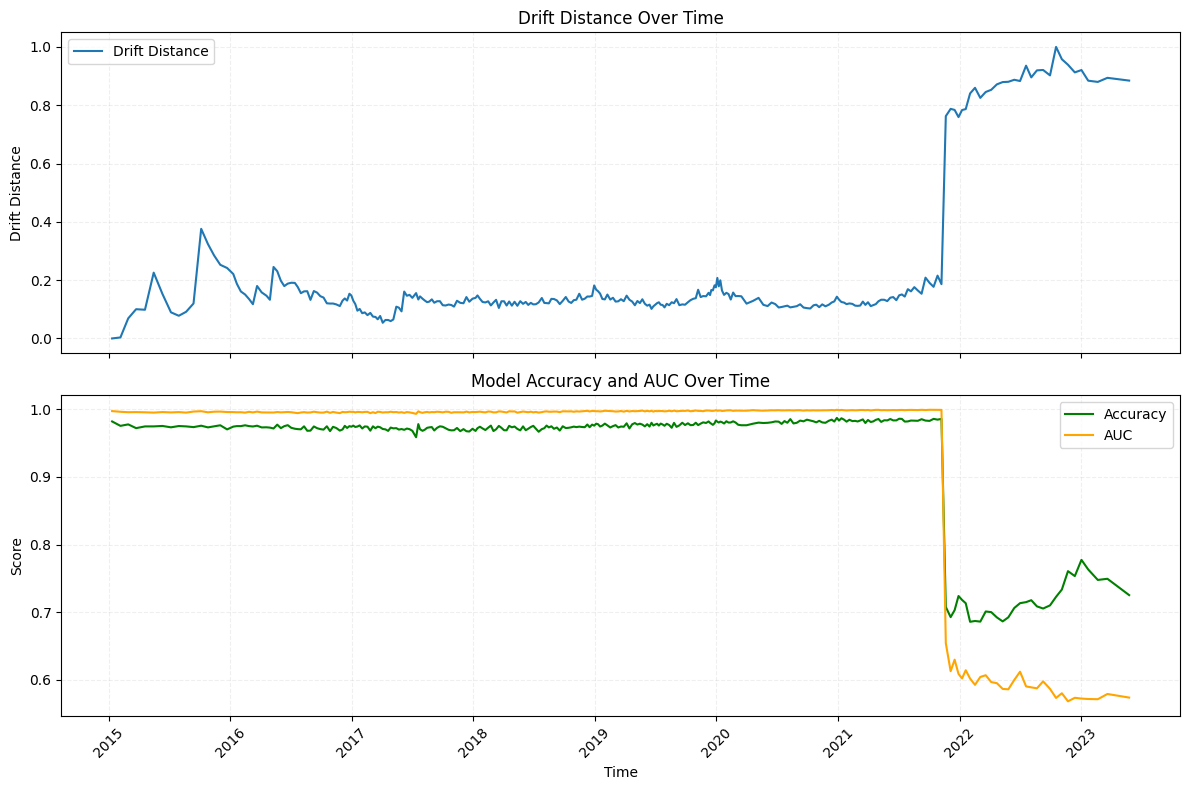

In [45]:
# Load the new CSV file
file_path_mmd = '/Users/jasper.bruin/Documents/driftwatch/driftwatch/baseline-experiment/baseline_results/2025-04-05_09-13-45/drift_detection_results_mmd_histogram.csv'
df_mmd = pd.read_csv(file_path_mmd)

# Convert window_time to datetime
df_mmd['window_time'] = pd.to_datetime(df_mmd['window_time'])

# Normalize drift distance to 0-1 scale
df_mmd['drift_distance'] = (df_mmd['drift_distance'] - df_mmd['drift_distance'].min()) / (df_mmd['drift_distance'].max() - df_mmd['drift_distance'].min())

# Set up the plot
fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Plot normalized drift distance
axs[0].plot(df_mmd['window_time'], df_mmd['drift_distance'], label='Drift Distance')
axs[0].set_ylabel('Drift Distance')
axs[0].set_title('Drift Distance Over Time')
axs[0].legend()
axs[0].grid(True, linestyle='--', alpha=0.2)


# Plot accuracy and AUC on the same plot
axs[1].plot(df_mmd['window_time'], df_mmd['accuracy'], color='green', label='Accuracy')
axs[1].plot(df_mmd['window_time'], df_mmd['auc'], color='orange', label='AUC')
axs[1].set_ylabel('Score')
axs[1].set_title('Model Accuracy and AUC Over Time')
axs[1].legend()
axs[1].grid(True, linestyle='--', alpha=0.2)

# Formatting the x-axis
plt.xlabel('Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("drift_detection_results_mmd_histogram.png", dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

In [46]:
import pandas as pd
import os
from glob import glob

# Set your directory path here
directory = '/Users/jasper.bruin/Documents/driftwatch/driftwatch/baseline-experiment/baseline_results/2025-04-05_09-13-45'

# Pattern to match files
file_pattern = os.path.join(directory, 'drift_detection_results_*.csv')

# List all matching files
file_list = glob(file_pattern)

# Load and combine files
all_dfs = []
for file_path in file_list:
    df = pd.read_csv(file_path)
    method = os.path.basename(file_path).replace('drift_detection_results_', '').replace('.csv', '')
    df['method'] = method
    all_dfs.append(df)

# Concatenate all dataframes
combined_df = pd.concat(all_dfs, ignore_index=True)

# Convert time if needed
combined_df['window_time'] = pd.to_datetime(combined_df['window_time'])

# Optional: Save to a new CSV
combined_df.to_csv('combined_drift_detection_results.csv', index=False)


In [47]:
combined_df

,window_time,drift_distance,threshold,drift_detected,accuracy,auc,method
0,2015-01-11 08:09:48.506820096,0.000000,0.018653,0,0.982081,0.997392,bhattacharyya_histogram
1,2015-02-05 05:45:21.200667648,0.002953,0.018653,0,0.975567,0.996395,bhattacharyya_histogram
2,2015-02-28 16:39:17.016885504,0.009618,0.018653,0,0.977754,0.995738,bhattacharyya_histogram
3,2015-03-24 08:51:32.283909632,0.013173,0.018653,0,0.972207,0.995922,bhattacharyya_histogram
4,2015-04-19 23:55:22.089075712,0.013299,0.018653,0,0.974760,0.995622,bhattacharyya_histogram
...,...,...,...,...,...,...,...
5695,2023-01-01 16:50:34.107695360,0.026632,0.037495,0,0.777524,0.572518,wasserstein_histogram
5696,2023-01-21 22:36:39.085148160,0.025938,0.036496,0,0.763360,0.571895,wasserstein_histogram
5697,2023-02-19 18:52:46.886860032,0.025502,0.034980,0,0.747860,0.571576,wasserstein_histogram
5698,2023-03-20 16:48:23.729529344,0.025473,0.032835,0,0.749561,0.579305,wasserstein_histogram


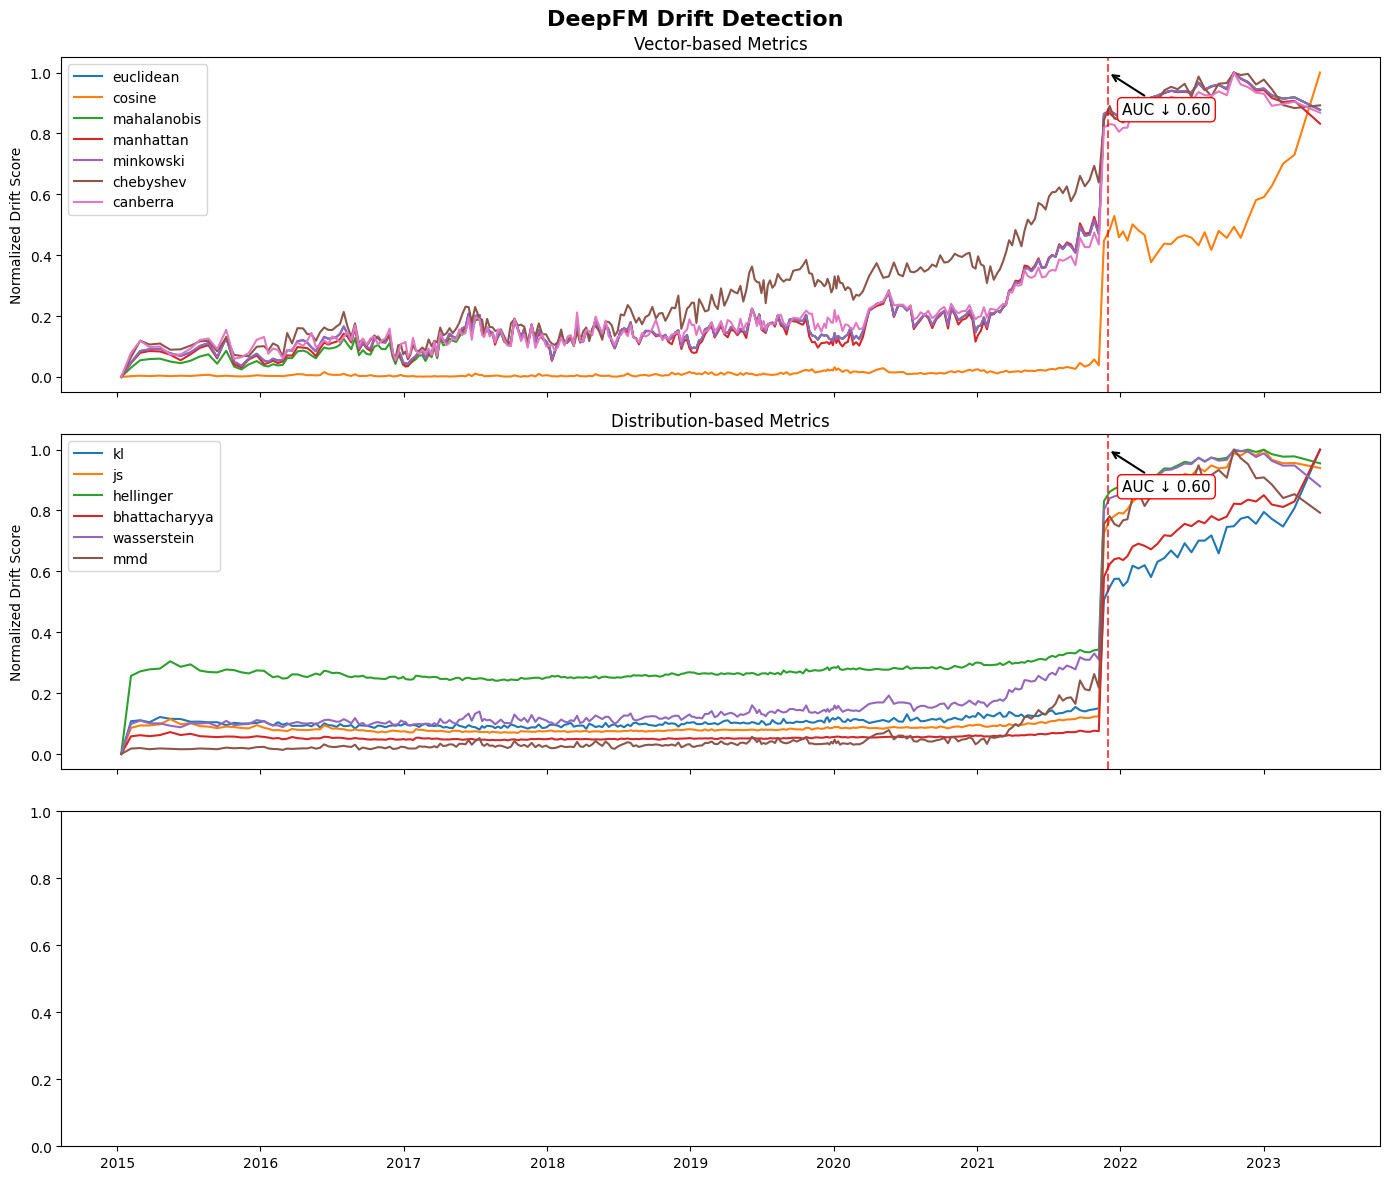

In [56]:
import matplotlib.pyplot as plt

# Make a copy to safely modify
merged_df = combined_df.copy()

# Define merging of histogram and kll into unified labels
merge_map = {
    'kl_kll': 'kl', 'kl_histogram': 'kl',
    'js_kll': 'js', 'js_histogram': 'js',
    'hellinger_kll': 'hellinger', 'hellinger_histogram': 'hellinger',
    'bhattacharyya_kll': 'bhattacharyya', 'bhattacharyya_histogram': 'bhattacharyya',
    'wasserstein_kll': 'wasserstein',  # no histogram version here
    'mmd_kll': 'mmd',  # no histogram version here
}

# Merge method names
merged_df['method'] = merged_df['method'].replace(merge_map)

# Group by method and time, averaging drift values
merged_df = merged_df.groupby(['method', 'window_time'], as_index=False).mean()

# Normalize per method
merged_df['normalized_drift'] = merged_df.groupby('method')['drift_distance'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min())
)

# Update method categories
vector_methods = ['euclidean', 'cosine', 'mahalanobis', 'manhattan', 'minkowski', 'chebyshev', 'canberra']
distribution_methods = ['kl', 'js', 'hellinger', 'bhattacharyya', 'wasserstein', 'mmd']

# Get AUC drop info from 2022
performance_df = merged_df[merged_df['method'] == 'euclidean']
drop_point = performance_df[performance_df['window_time'].dt.year == 2022]
if not drop_point.empty:
    auc_2022 = drop_point.iloc[0]['auc']
    time_2022 = pd.to_datetime('2021-12-01')
    auc_annotation = f'AUC ↓ {auc_2022:.2f}'
else:
    # Fallback if no data found at 2022
    time_2022 = pd.to_datetime('2021-12-01')
    auc_annotation = 'AUC Drop'

# Set up the plot
fig, axs = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
fig.suptitle('DeepFM Drift Detection', fontsize=16, fontweight='bold')

# Panel 1: Vector-based
for method in vector_methods:
    subset = merged_df[merged_df['method'] == method]
    axs[0].plot(subset['window_time'], subset['normalized_drift'], label=method)
axs[0].axvline(x=time_2022, color='red', linestyle='--', alpha=0.7)
axs[0].annotate(
    auc_annotation,
    xy=(time_2022, 1), xycoords='data',
    xytext=(10, -30), textcoords='offset points',
    arrowprops=dict(facecolor='red', arrowstyle='->', lw=1.5),
    fontsize=11,
    color='black',
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="red", lw=1)
)
axs[0].set_title('Vector-based Metrics')
axs[0].set_ylabel('Normalized Drift Score')
axs[0].legend()

# Panel 2: Distribution-based
for method in distribution_methods:
    subset = merged_df[merged_df['method'] == method]
    axs[1].plot(subset['window_time'], subset['normalized_drift'], label=method)
axs[1].axvline(x=time_2022, color='red', linestyle='--', alpha=0.7)
axs[1].annotate(
    auc_annotation,
    xy=(time_2022, 1), xycoords='data',
    xytext=(10, -30), textcoords='offset points',
    arrowprops=dict(facecolor='red', arrowstyle='->', lw=1.5),
    fontsize=11,
    color='black',
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="red", lw=1)
)
axs[1].set_title('Distribution-based Metrics')
axs[1].set_ylabel('Normalized Drift Score')
axs[1].legend()


# Panel 3: AUC and Accuracy (from any one method, e.g., 'euclidean')
performance_df = merged_df[merged_df['method'] == 'euclidean']
axs[2].plot(performance_df['window_time'], performance_df['accuracy'], label='Accuracy', color='green')
axs[2].plot(performance_df['window_time'], performance_df['auc'], label='AUC', color='orange')
axs[2].set_title('Model Performance Over Time')
axs[2].set_ylabel('Score')
axs[2].set_xlabel('Time')
axs[2].legend()

plt.tight_layout()
plt.show()

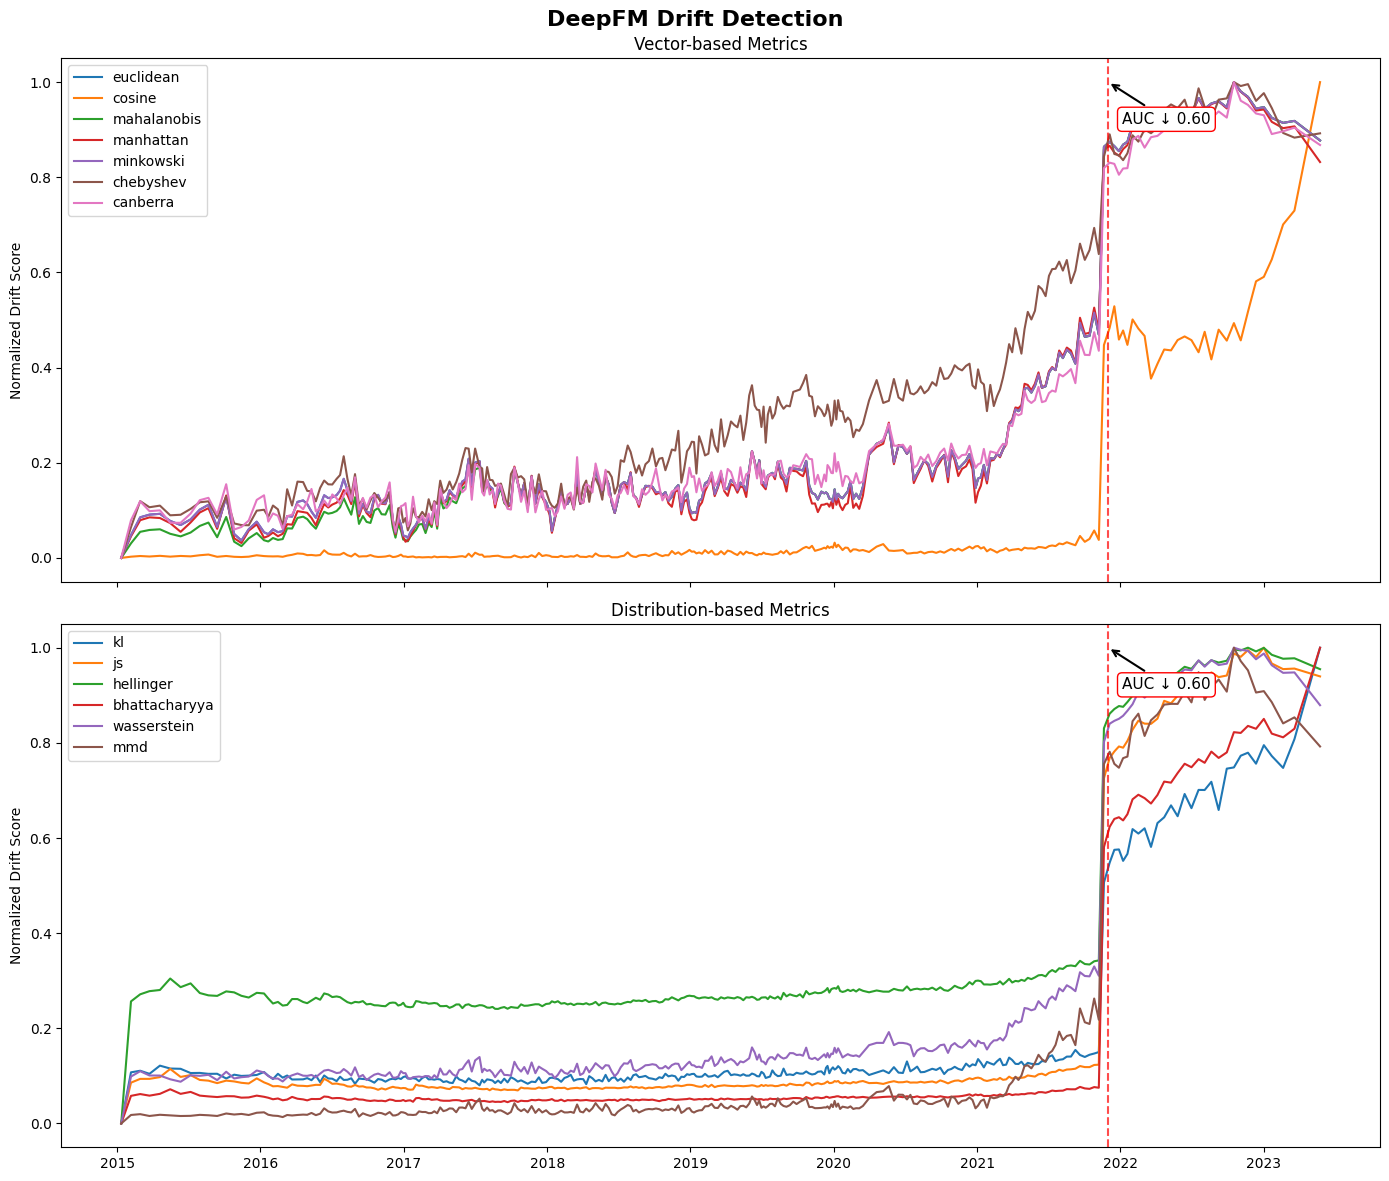

In [59]:
import matplotlib.pyplot as plt

# Make a copy to safely modify
merged_df = combined_df.copy()

# Define merging of histogram and kll into unified labels
merge_map = {
    'kl_kll': 'kl', 'kl_histogram': 'kl',
    'js_kll': 'js', 'js_histogram': 'js',
    'hellinger_kll': 'hellinger', 'hellinger_histogram': 'hellinger',
    'bhattacharyya_kll': 'bhattacharyya', 'bhattacharyya_histogram': 'bhattacharyya',
    'wasserstein_kll': 'wasserstein',  # no histogram version here
    'mmd_kll': 'mmd',  # no histogram version here
}

# Merge method names
merged_df['method'] = merged_df['method'].replace(merge_map)

# Group by method and time, averaging drift values
merged_df = merged_df.groupby(['method', 'window_time'], as_index=False).mean()

# Normalize per method
merged_df['normalized_drift'] = merged_df.groupby('method')['drift_distance'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min())
)

# Update method categories
vector_methods = ['euclidean', 'cosine', 'mahalanobis', 'manhattan', 'minkowski', 'chebyshev', 'canberra']
distribution_methods = ['kl', 'js', 'hellinger', 'bhattacharyya', 'wasserstein', 'mmd']

# Get AUC drop info from 2022
performance_df = merged_df[merged_df['method'] == 'euclidean']
drop_point = performance_df[performance_df['window_time'].dt.year == 2022]
if not drop_point.empty:
    auc_2022 = drop_point.iloc[0]['auc']
    time_2022 = pd.to_datetime('2021-12-01')
    auc_annotation = f'AUC ↓ {auc_2022:.2f}'
else:
    # Fallback if no data found at 2022
    time_2022 = pd.to_datetime('2021-12-01')
    auc_annotation = 'AUC Drop'

# Set up the plot
fig, axs = plt.subplots(2, 1, figsize=(14, 12), sharex=True)
fig.suptitle('DeepFM Drift Detection', fontsize=16, fontweight='bold')

# Panel 1: Vector-based
for method in vector_methods:
    subset = merged_df[merged_df['method'] == method]
    axs[0].plot(subset['window_time'], subset['normalized_drift'], label=method)
axs[0].axvline(x=time_2022, color='red', linestyle='--', alpha=0.7)
axs[0].annotate(
    auc_annotation,
    xy=(time_2022, 1), xycoords='data',
    xytext=(10, -30), textcoords='offset points',
    arrowprops=dict(facecolor='red', arrowstyle='->', lw=1.5),
    fontsize=11,
    color='black',
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="red", lw=1)
)
axs[0].set_title('Vector-based Metrics')
axs[0].set_ylabel('Normalized Drift Score')
axs[0].legend()

# Panel 2: Distribution-based
for method in distribution_methods:
    subset = merged_df[merged_df['method'] == method]
    axs[1].plot(subset['window_time'], subset['normalized_drift'], label=method)
axs[1].axvline(x=time_2022, color='red', linestyle='--', alpha=0.7)
axs[1].annotate(
    auc_annotation,
    xy=(time_2022, 1), xycoords='data',
    xytext=(10, -30), textcoords='offset points',
    arrowprops=dict(facecolor='red', arrowstyle='->', lw=1.5),
    fontsize=11,
    color='black',
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="red", lw=1)
)
axs[1].set_title('Distribution-based Metrics')
axs[1].set_ylabel('Normalized Drift Score')
axs[1].legend()

plt.tight_layout()
plt.show()